In [1]:
%load_ext autoreload
import torch
import numpy as np
import l4casadi as l4c
import casadi as cas
from models import *
from utils.data_loader import *
import utils.utilities as utilities
torch.backends.mkldnn.flags.rnn = False
torch.backends.mkldnn.enabled = False
from mpc_class import MPC
from scipy.linalg import solve_discrete_lyapunov
import control as ctrl

Notes to self:

~~Xf is f+1st NOT fth, need to calculate next state after last input!!!~~ THIS IS NOT TRUE, coz we start with x1,u0. So we calculate (u1,u2,u3,u4,u5) and (x2,...,x6=xf)
 \
ADD MAYBE TERMINAL CONSTRAINT

Loading data and models

In [2]:
%autoreload 2
parent = ''
filter = pd.concat([pd.read_csv(parent+'data/nodes/c1.csv'),pd.read_csv(parent+'data/nodes/c2.csv'),pd.read_csv(parent+'data/nodes/sus.csv'),pd.read_csv(parent+'data/nodes/outer_wall.csv')])
data_dict,mu_dict,nodes,_ = load_raw_data(parent+'data/raw_data/', filter3D=filter, mu_keys=['Power 3D (kW)', 'Cooling Power 3D (kW)', 'Pyro 3D (°C)'])      

In [3]:

manager = DatasetManager(
    data_dict=data_dict, 
    mu_dict=mu_dict, 
    train_share=0.8, 
    valid_share=0.1, 
    POD_dim=10, 
    seq_len=10,
    padding_key = ['zero', 'zero', 'init']
    )
train_dataset, valid_dataset, test_dataset = manager.make_SHRED_datasets(ykey='POD_coefs')

/home/abhyu/Documents/SINTEF/Gitlab/clean_start/utils/utilities.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.stdev = torch.tensor(np.sqrt(self.var), dtype =torch.float32)


In [4]:
shred = SHRED(
   in_dim=train_dataset.X.shape[-1],
   out_dim=train_dataset.Y.shape[-1],
   batch_first=True,
   data_manager=manager,
   lstm_params= {
                  'seq_len': 10, 
                  'n_layers': 2,
                  'hidden_dim': 64,
               },
   sdn_params = {
                  'inner_layers': [200,100],
                  'dropout': [True, 0.1],
                  'batch_norm': [False],
               },
            )
weights = torch.load('shred_2.json', weights_only=True)
shred.load_state_dict(weights)
shred.eval()
train_dataset_forecaster, valid_dataset_forecaster, test_dataset_forecaster = manager.make_FORECASTER_datasets(shred, padding_key=['zero', 'zero', 'init'])

Remove unwated

In [5]:
remove_idx = 1 #Removing cooling power
mask = torch.ones(train_dataset_forecaster.X.shape[-1],dtype=torch.bool)
mask[remove_idx] = False
train_dataset_forecaster.X = train_dataset_forecaster.X[:,:,mask]
valid_dataset_forecaster.X = valid_dataset_forecaster.X[:,:,mask]
test_dataset_forecaster.X = test_dataset_forecaster.X[:,:,mask]


In [6]:
forecaster = SHREDForecaster(
    u_dim=train_dataset_forecaster.X.shape[-1], 
    out_dim=train_dataset_forecaster.Y.shape[-1], 
    lstm_params = {
                'seq_len': 10, 
                'n_layers': 1,
                'hidden_dim': 64,
                },
    batch_first=True,
    data_manager=None,
)
forecaster_weights = torch.load('forecaster_weights_4.json')
forecaster.load_state_dict(forecaster_weights)
forecaster.eval()

SHREDForecaster(
  (lstm): LSTM(
    (lstm): LSTM(66, 64, batch_first=True)
  )
  (proj): Linear(in_features=64, out_features=64, bias=True)
)

In [7]:
c1_picker = torch.tensor(np.loadtxt('data/core_regions/c1_picker.txt'), dtype=torch.float32)
c2_picker = torch.tensor(np.loadtxt('data/core_regions/c2_picker.txt'), dtype=torch.float32)
sus_picker = torch.tensor(np.loadtxt('data/core_regions/sus_picker.txt'), dtype=torch.float32)
outer_wall_picker = torch.tensor(np.loadtxt('data/core_regions/outer_wall_picker.txt'), dtype=torch.float32)
pyro_picker = torch.tensor(np.loadtxt('data/core_regions/pyro_picker.txt'), dtype=torch.float32)
# n2 = 100  # number of rows to keep
# torch.manual_seed(42)  # Any integer seed
# c1_idx  = torch.randperm(c1_picker.shape[0])[:n2]
# c2_idx  = torch.randperm(c2_picker.shape[0])[:n2]
# sus_idx = torch.randperm(sus_picker.shape[0])[:n2]
# c1_picker  = c1_picker[c1_idx]
# c2_picker  = c2_picker[c2_idx]
# sus_picker = sus_picker[sus_idx]
# picker = torch.cat([c1_picker, c2_picker, -1*sus_picker])

In [8]:
seq_len = train_dataset_forecaster.X.shape[1]
out_dim = train_dataset_forecaster.Y.shape[-1]
u_dim   = train_dataset_forecaster.X.shape[-1] - out_dim
f = 5                             
c1_target = 2000
c2_target = 2000
sus_target = -2500

# target = torch.cat([c1_target*torch.ones((c1_picker.shape[0],1)), c2_target*torch.ones((c2_picker.shape[0],1)), sus_target*torch.ones((sus_picker.shape[0],1))]).T
# target = torch.cat([target for _ in range(f)],dim=1).T

Setting equilibiurm point and loading linear controller (from linearized LQR files)

In [9]:
# Z_tilde = manager.Yscaler.inverse_transform(test_dataset.Y[30])
# np.savetxt('data/mpc_files/Z_tilde.txt', Z_tilde.detach())
u_tilde_prev = test_dataset_forecaster.X[30,:,:u_dim]
x_tilde_prev = test_dataset_forecaster.X[30,:,u_dim:]
np.savetxt('data/mpc_files/u_tilde_prev.txt', u_tilde_prev.detach())
np.savetxt('data/mpc_files/x_tilde_prev.txt', x_tilde_prev.detach())


In [10]:
%autoreload 2
build_dir = '_forecasterl4c_'
l4c_model = l4c.L4CasADi(forecaster, device='cpu', build_dir=build_dir, generate_jac_jac=False)
if build_dir in os.listdir():
    print('FOUND EXISTING l4casadi build. Loading...')
    l4c_model._built = True
    l4c_model._input_shape  = (seq_len, u_dim+out_dim)
    l4c_model._output_shape = (1, out_dim)
else:
    print('No such directory, building new model...')

print('Defining the casadi function')
X_sym = cas.MX.sym('X', seq_len, u_dim+out_dim)
print(X_sym.shape)
print(l4c_model._input_shape)
y_sym = l4c_model(X_sym)
f = cas.Function('J', [X_sym], [y_sym])
df = cas.Function('grad_f', [X_sym], [cas.jacobian(f(X_sym), X_sym)])

FOUND EXISTING l4casadi build. Loading...
Defining the casadi function
(10, 66)
(10, 66)


In [11]:
def B_func(X): # Dependence on last input, not full seq
    return np.array(df(X)[:,u_dim*(seq_len-1):u_dim*(seq_len)])

def A_func(X): #Dependence on last state, not full seq
    return np.array(df(X)[:,u_dim*(seq_len)+64*(seq_len-1):])

X_prev = np.hstack([u_tilde_prev.detach().numpy(), x_tilde_prev.detach().numpy()])

A = A_func(X_prev)
B = B_func(X_prev)
print(A.shape, B.shape)

Q = np.diag(np.ones(out_dim))
R = np.diag(np.ones(u_dim))

# PBH test — check each eigenvalue
n = A.shape[0]
eigenvalues = np.linalg.eigvals(A)
all_ctrb = True
for lam in eigenvalues:
    PBH = np.hstack([-A + lam * np.eye(n), B])
    r = np.linalg.matrix_rank(PBH)
    
    c = r == n
    if not c:
        print(f"λ = {lam:.2f} → {'Controllable' if c else 'UNCONTROLLABLE'}")
        all_ctrb = False
if all_ctrb:
    print('All modes are controllable, so the system is controllable.')

K_f, S, eigs = ctrl.dlqr(A,B,Q,R)
Ak = A - B@K_f
Qk = Q + K_f.T @ R @ K_f
mu = 1.0001
P = solve_discrete_lyapunov(Ak, mu*Qk)
print('The terminal cost is V_f(x) = x^TPx')
# print(np.linalg.eig(P).eigenvalues.max())
L = np.linalg.cholesky(P)
matrix_folder = 'data/mpc_files/'
np.savetxt(matrix_folder+'Qkmatrix.txt', Qk)
np.savetxt(matrix_folder+'Kmatrix.txt', K_f)
np.savetxt(matrix_folder+'Pmatrix.txt', P)

(64, 64) (64, 2)
All modes are controllable, so the system is controllable.
The terminal cost is V_f(x) = x^TPx


In [12]:
K_f = torch.tensor(np.loadtxt('data/mpc_files/Kmatrix.txt'),dtype=torch.float32)
P = torch.tensor(np.loadtxt('data/mpc_files/Pmatrix.txt'),dtype=torch.float32)
cooling = torch.tensor(np.loadtxt('data/cooling_avg.txt'),dtype=torch.float32)


Setting up MPC object

In [13]:
%autoreload 2
f = 5
mpc_worker = MPC(shred,
                 forecaster,
                 manager,
                 f,
                 seq_len,
                 u_dim,
                 out_dim,
                 K_f,
                 P,
                 u_tilde_prev[-1],
                 x_tilde_prev[-1],
                 cooling,
                 c1_picker,
                 c2_picker,
                 sus_picker,
                 outer_wall_picker,
                 pyro_picker,
                 c1_target,
                 c2_target,
                 sus_target,
                 np.loadtxt('data/cooling_coef.txt'),
                 )
cost_single_shootting,cost_multiple_shooting = mpc_worker.make_cost_model()



In [ ]:
cost_single_shootting(torch.zeros((1,665)))

torch.Size([4184])

In [18]:
%autoreload 2
build_dir = '_singleshootingl4c_Vf_2'
cost_sym, grad_cost_sym = mpc_worker.create_sym(cost_single_shootting, build_dir, 'cost_single_shooting')


(665, 1) (1, 1)
No such directory, building new model...
Defining the casadi function


/home/abhyu/miniconda3/envs/shred_env/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)


In [19]:
solver_single_shooting = mpc_worker.set_up_single_shooting(cost_sym)

Setting up preliminaries for solving

In [20]:
%autoreload 2
u_prev = test_dataset_forecaster.X[0,:-1,:u_dim]
x_prev = test_dataset_forecaster.X[0][:,u_dim:]
p_plan = manager.Pscaler.inverse_transform(0.9*torch.ones((f,1), dtype=torch.float32))
p_cool0 = torch.zeros((1,), dtype=torch.float32)
T_pyro0 =  torch.zeros((1,), dtype=torch.float32)


In [39]:
Z0 = shred.post(shred.sdn(test_dataset_forecaster.Y[0])).reshape(1,-1)

Single shooting w/ terminal cost

Warm start is unscaled, scaling...
----------1----------
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  | 589.61ms ( 31.03ms)  75.55ms (  3.98ms)        19
  nlp_grad_f  |   1.54 s (102.34ms) 192.70ms ( 12.85ms)        15
       total  |   2.40 s (  2.40 s) 304.16ms (304.16ms)         1
tensor([[1.0000, 0.1032]], grad_fn=<ViewBackward0>)
----------2----------
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |   5.72 s ( 29.97ms) 727.84ms (  3.81ms)       191
  nlp_grad_f  |   2.56 s ( 91.41ms) 325.22ms ( 11.62ms)        28
       total  |   8.81 s (  8.81 s)   1.11 s (  1.11 s)         1
tensor([[1.0000, 0.2702]], grad_fn=<ViewBackward0>)
----------3----------
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |   4.76 s ( 30.12ms) 597.33ms (  3.78ms)       158
  nlp_grad_f  |   2.66 s ( 94.82ms) 333.16ms ( 11.90ms)        28
       total  |   7.86 s (  7.86 s) 990.33ms (990.33ms)         1
ten

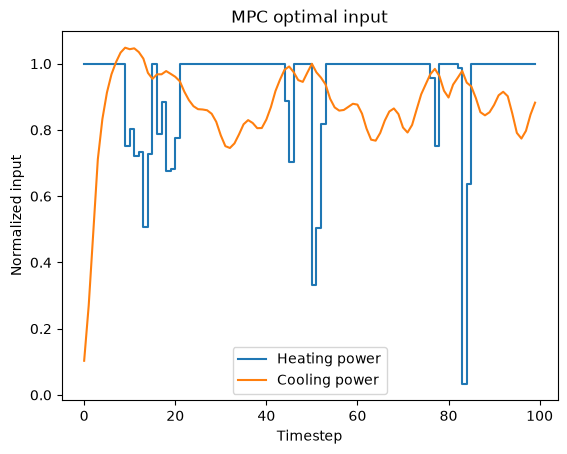

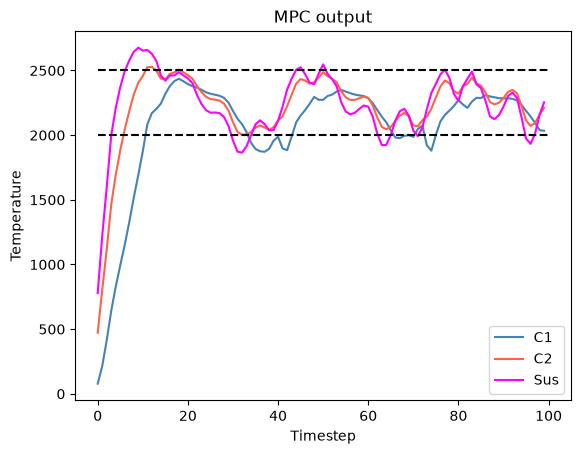

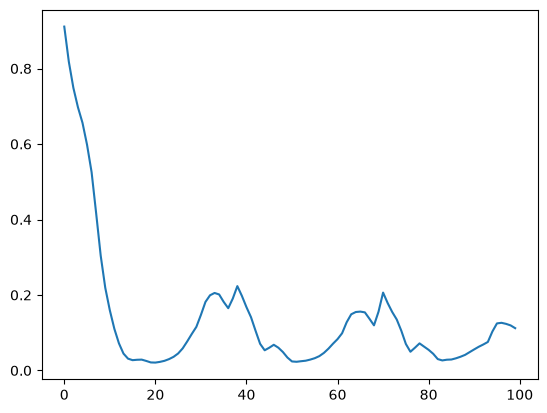

In [27]:
Uopt, Xopt, Zopt = mpc_worker.single_shooting(
    solver=solver_single_shooting,
    n_steps=100,
    u_prev=u_prev,
    x_prev=x_prev,
    p_plan0=p_plan,
    p_cool0=None,
    T_pyro0=T_pyro0,
    plotting=True,
    Vf_toggle=1,
    Emax=1,
)

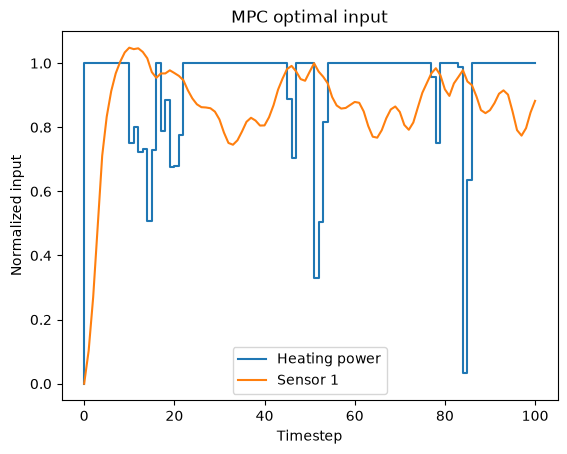

torch.Size([1, 4184]) torch.Size([100, 4184])


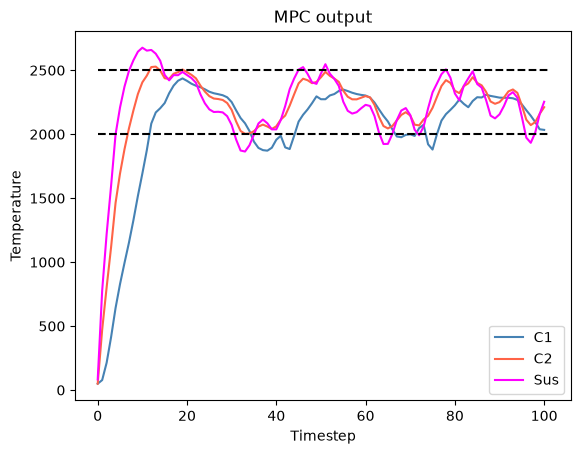

In [41]:
U0 = torch.zeros((1,2))
mpc_worker.make_plots(Uopt, Xopt, Zopt, U0, Z0, extra_plots=True)

Single shooting w/o terminal cost

Warm start is unscaled, scaling...
----------1----------
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  66.00ms (  1.74ms)  67.20ms (  1.77ms)        38
  nlp_grad_f  |  81.00ms (  4.26ms) 103.43ms (  5.44ms)        19
       total  | 201.00ms (201.00ms) 200.78ms (200.78ms)         1
tensor([1.8661e+03, 9.3305e-01, 6.4102e-16], grad_fn=<SelectBackward0>)
----------2----------
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  21.00ms (  1.50ms)  24.93ms (  1.78ms)        14
  nlp_grad_f  |  45.00ms (  5.62ms)  47.20ms (  5.90ms)         8
       total  |  89.00ms ( 89.00ms)  88.90ms ( 88.90ms)         1
tensor([1.8661e+03, 1.8661e+00, 6.5150e-05], grad_fn=<SelectBackward0>)
----------3----------
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  15.00ms (833.33us)  31.07ms (  1.73ms)        18
  nlp_grad_f  |  87.00ms (  6.21ms)  71.77ms (  5.13ms)        14
       total  | 123.00ms (123

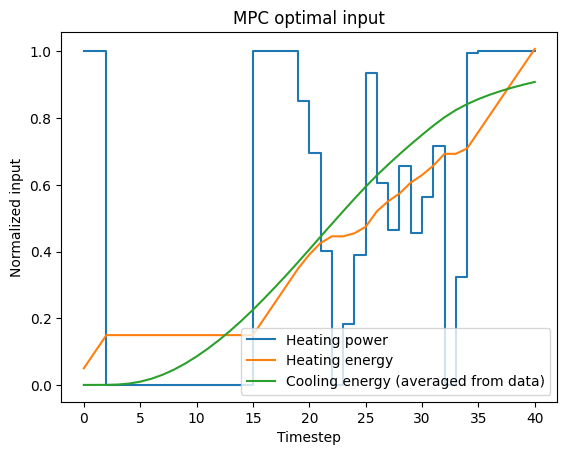

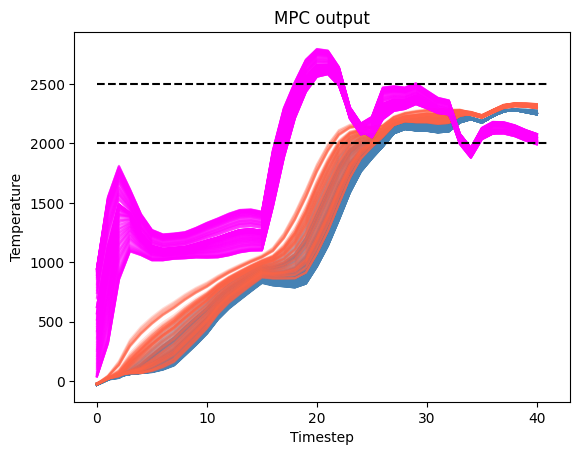

In [ ]:
%autoreload 2
Uopt, Xopt, Zopt = mpc_worker.single_shooting(
    solver=solver_single_shooting,
    n_steps=50,
    u_prev=u_prev,
    x_prev=x_prev,
    cooling_plan=cooling,
    u0=u_plan,
    plotting=True,
    Vf_toggle=0,
    Emax=2
)

Multiple-shooting w/ terminal cost

In [63]:
build_dir = '_multipleshootingl4c_alt_target_'
cost_sym, grad_cost_sym = mpc_worker.create_sym(cost_multiple_shooting, build_dir, 'cost_multiple_shooting')
build_dir = '_forecasterl4c_multi_'
forecaster_sym, _ = mpc_worker.create_sym(forecaster, build_dir, 'forecaster')
solver_multiple_shooting = mpc_worker.set_up_multiple_shooting(forecaster_sym, cost_sym)

FOUND EXISTING l4casadi build. Loading...
Defining the casadi function
FOUND EXISTING l4casadi build. Loading...
Defining the casadi function
(27, 1) (640, 1) (5, 1) (5, 1)


In [64]:
%autoreload 2
u_prev = test_dataset_forecaster.X[0,:-1,:3]
x_prev = test_dataset_forecaster.X[0,:,3:]
p_plan = manager.Pscaler.inverse_transform(0.8*torch.ones((f,1)))
E_plan = utilities.integrate_series(p_plan)/1000 #kWh to MWh
C_plan = cooling[:f].reshape(-1,1)
u_plan = torch.cat([p_plan, E_plan, C_plan], dim=1)

Warm start is unscaled, scaling...
----------1----------
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |   9.00ms (409.09us)  13.99ms (635.91us)        22
       nlp_g  |  31.00ms (  1.41ms)  30.99ms (  1.41ms)        22
  nlp_grad_f  |  28.00ms (  1.33ms)  37.02ms (  1.76ms)        21
   nlp_jac_g  | 792.00ms ( 37.71ms) 793.18ms ( 37.77ms)        21
       total  |   1.17 s (  1.17 s)   1.17 s (  1.17 s)         1
tensor([1.8661e+03, 9.3305e-01, 6.4102e-16], grad_fn=<SelectBackward0>)
----------2----------
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  | 328.00ms (513.30us) 300.38ms (470.08us)       639
       nlp_g  | 786.00ms (  1.23ms) 785.76ms (  1.23ms)       640
  nlp_grad_f  | 133.00ms (  1.66ms) 139.20ms (  1.74ms)        80
   nlp_jac_g  |   3.95 s ( 38.03ms)   3.95 s ( 37.97ms)       104
       total  |   6.91 s (  6.91 s)   6.91 s (  6.91 s)         1
tensor([1.8513e+03, 1.8587e+00, 6.5150e-05], grad_fn=<Sel

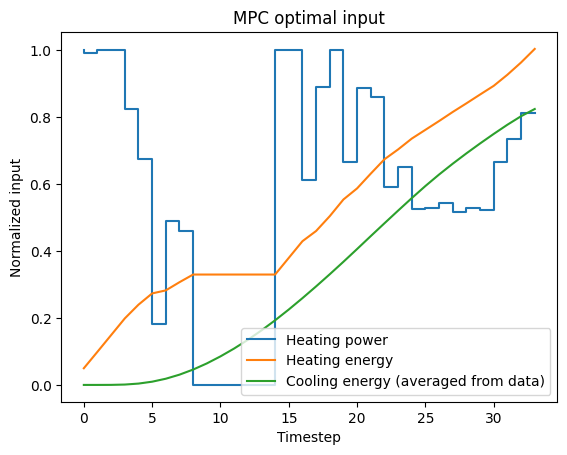

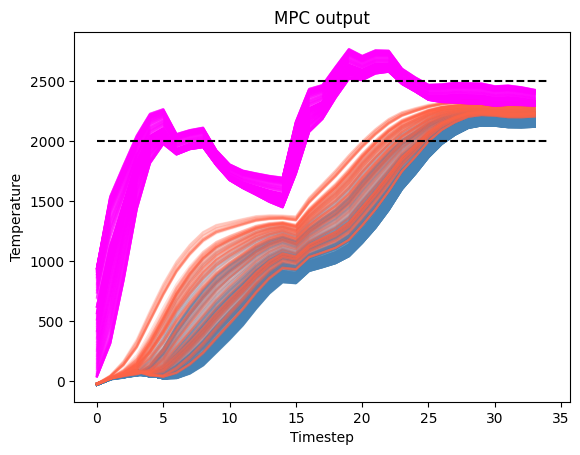

In [65]:
Uopt,Xpred,Zpred = mpc_worker.multiple_shooting(
    solver=solver_multiple_shooting,
    n_steps=50,
    u_prev=u_prev,
    x_prev=x_prev,
    cooling_plan=cooling,
    u0=u_plan,
    plotting=True,
    Vf_toggle=0,
    Emax=1,
)

Testing l4c model

In [26]:
u = np.zeros((5,1))
param = np.zeros((678,1))
u_dm = cas.DM(u)               # shape (5,1)
param_dm = cas.DM(param)       # shape (N,1)
x_full = cas.vertcat(u_dm, param_dm)

print("calling J...")
val = J(x_full)
print("J ok:", val)

calling J...
J ok: 0.294846


In [27]:
print("calling dJ...")
grad_val = dJ(x_full)
print("dJ ok:", grad_val)

calling dJ...
dJ ok: [-0.00578891, -0.0492527, -0.0551184, 6.16242e-05, -0.0426003, -0.0494933, 0.00625134, -0.0346604, -0.041641, 0.0087519, -0.0239216, -0.0296536, 0.00951591, -0.0136977, -0.0174058, 0.00156906, -0.00109481, -0.00102855, 0.00349897, -0.00247451, -0.00230607, 0.00541001, -0.00415959, -0.0038675, 0.00704031, -0.00616172, -0.00574353, 0.00811059, -0.00861754, -0.00811613, 0.0076264, -0.0113132, -0.0108363, 0.00567668, -0.0150014, -0.0147959, 0.00204273, -0.0206041, -0.0211457, -0.00304795, -0.030403, -0.0326025, -0.00197447, -0.000622303, -0.00273521, -0.000474054, -0.000536676, 0.00106967, -0.00369633, 0.00126864, -0.000593711, -0.000897774, -0.000376135, -0.00123053, -0.00101014, -0.00019399, 0.0019675, 0.0015494, 0.000566504, -0.0029094, -5.03739e-06, -0.00088689, -0.000747875, -0.00121325, 0.00269003, -0.00124461, -2.77853e-05, 0.000601637, -0.0014775, -0.00180824, -0.000432529, 0.00192894, 0.00250297, 0.00415973, -0.00278846, 1.63639e-05, 0.00110685, -0.000708349, 

Debugging

In [254]:
u_prev  = test_dataset_forecaster.X[0,:-1,:3]
x_prev  = test_dataset_forecaster.X[0][:,3:]
u_plan  = test_dataset_forecaster.X[:60,-1,:3]
p_plan  = u_plan[:,0]
p_cool0 = u_plan[0,1].reshape(1,)
E_net0  = u_plan[0,2].reshape(1,)
Z,X,U=cost_single_shootting.pred_loop(p_plan=p_plan, p_cool0_s=p_cool0, E_net0_s=E_net0, u_prev=u_prev, x_prev=x_prev)

# Z,(X,U,P_cool)=cost_single_shootting.pred_loop_(u_plan=u_plan, u_prev=u_prev, x_prev=x_prev)
Z2 = pred = shred.post(shred.sdn(forecaster(test_dataset_forecaster.X[:60]))).detach()
Z_true = shred.post(shred.sdn(test_dataset_forecaster.Y[:60])).detach()

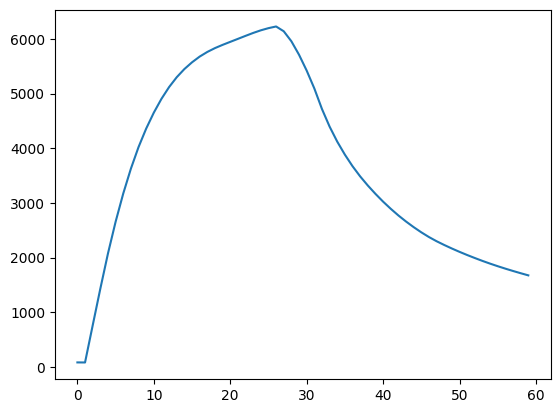

In [233]:
plt.plot(E_net.detach())

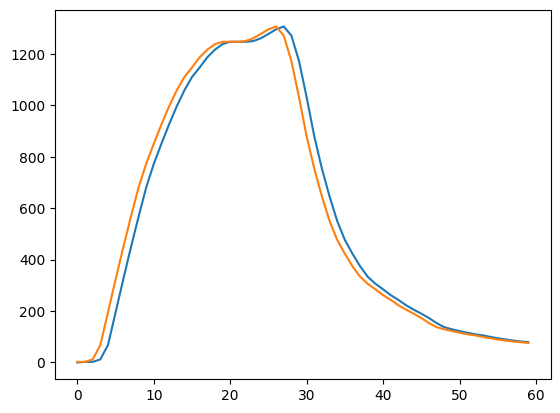

In [234]:
plt.plot(manager.Uscaler.inverse_transform(U)[:,1].detach())
plt.plot(P_cool.detach())

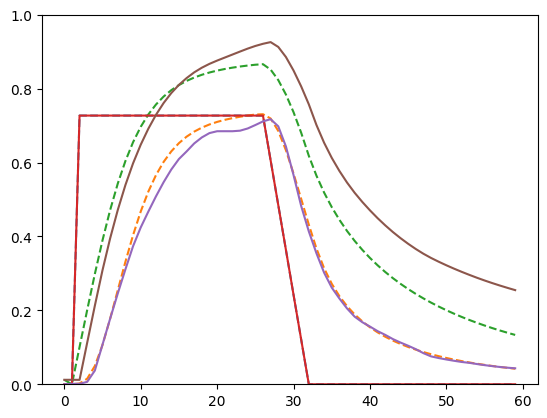

In [255]:
plt.plot(u_plan.detach(), ls='dashed')
plt.ylim((0,1))
# plt.show()
plt.plot(U.detach())
plt.ylim((0,1))
plt.show()


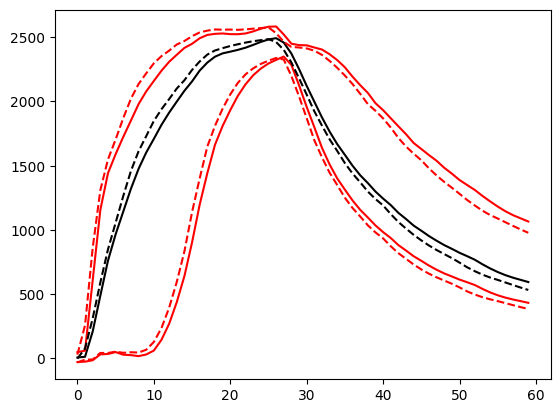

In [245]:
pick = c2_picker
c1_1 = Z.detach() @ pick.T
c1_true = Z_true @ pick.T
c1_2 = Z2.detach() @ pick.T
plt.plot(c1_1.mean(dim=1), color='black')
plt.plot(c1_1.max(dim=1)[0], color='red')
plt.plot(c1_1.min(dim=1)[0], color='red')
# plt.show()
# plt.plot(c1_2.mean(dim=1))
# plt.plot(c1_2.max(dim=1)[0])
# plt.plot(c1_2.min(dim=1)[0])
# plt.show()
plt.plot(c1_true.mean(dim=1), color='black', ls='dashed')
plt.plot(c1_true.max(dim=1)[0], color='red', ls='dashed')
plt.plot(c1_true.min(dim=1)[0] ,color='red', ls='dashed')
plt.show()

In [265]:
import plotly.graph_objects as go
mean = c1_1.mean(dim=1)
lower = c1_1.min(dim=1)[0]
upper = c1_1.max(dim=1)[0]
t = np.arange(len(mean))

fig = go.Figure([
    go.Scatter(x=t, y=upper, mode='lines', line=dict(width=0), showlegend=False),
    go.Scatter(x=t, y=lower, mode='lines', line=dict(width=0), fill='tonexty', fillcolor='rgba(0,100,255,0.2)', name='Min–Max range'),
    go.Scatter(x=t, y=mean, mode='lines', line=dict(color='blue'), name='Mean'),
])
fig.update_layout(xaxis_title='Time', yaxis_title='Temperature')
fig.show()

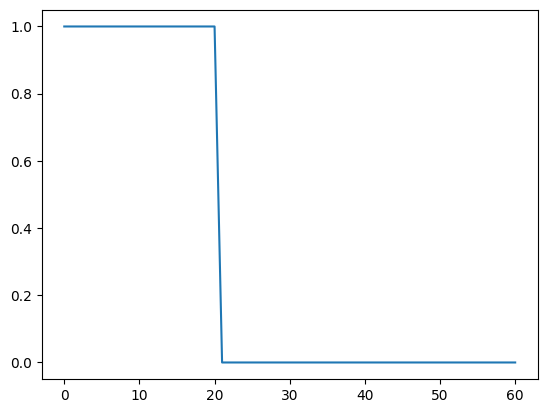

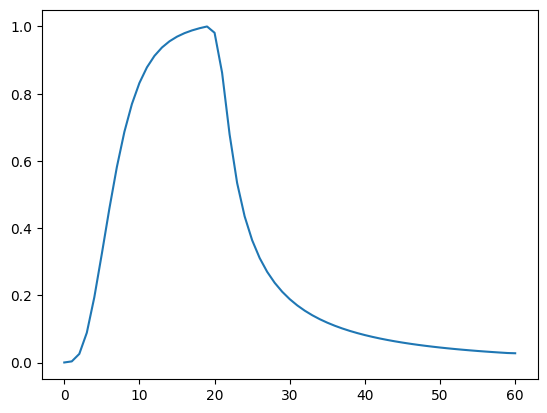

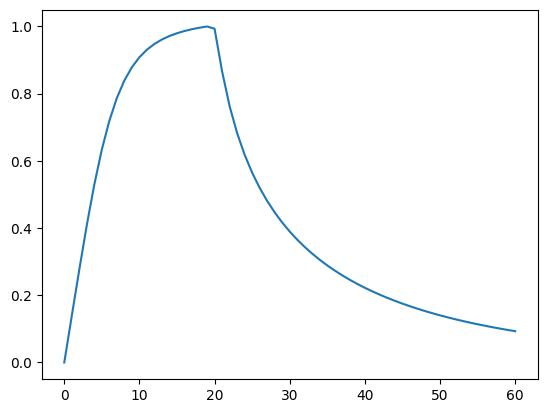

In [92]:
U_og = manager.Uscaler.transform(torch.tensor(mu_dict['PW1']['mu'][:,:3],dtype=torch.float32))
for k in range(U_og.shape[1]):
    plt.plot(U_og[:,k].detach())
    plt.show()